In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

In [2]:
import pandas as pd
# seperator is comma not ;
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv", sep=',')
data = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"
!wget $data -O course_lead_scoring.csv

--2025-10-20 01:34:34--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.01s   

2025-10-20 01:34:34 (7.22 MB/s) - ‘course_lead_scoring.csv’ saved [80876/80876]



In [3]:

# df.head(20)

In [4]:
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count' , 'lead_score']
categorical = ['industry', 'employment_status', 'location']

In [5]:


# data cleaning and preprocessing
df.columns = df.columns.str.lower().str.replace(' ', '_')
# remove unwanted spaces from column names
df.columns = df.columns.str.strip()

df.fillna("_", inplace=True)


df['annual_income'] = pd.to_numeric(df['annual_income'], errors='coerce')
df['annual_income'] = df['annual_income'].fillna(0)
 

/tmp/ipykernel_2065/1917041089.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '_' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("_", inplace=True)


In [6]:
# df.head(20)


In [7]:
# setup train, val, test splits
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
 
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
 
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
 
del df_train['converted']
del df_val['converted']
del df_test['converted'] 

In [8]:
df_train.fillna(0, inplace=True)
df_val.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)

In [9]:
dv = DictVectorizer(sparse=False)
 
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)
 
y_pred = model.predict_proba(X_val)[:, 1]
converted_decision = (y_pred >= 0.5)
(y_val == converted_decision).mean()

np.float64(0.7030716723549488)

In [11]:
# people who are going to convert
actual_positive = (y_val == 1)
# people who are not going to convert
actual_negative = (y_val == 0)
# threshold
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [12]:
predict_positive & actual_positive

array([ True, False,  True, False,  True,  True,  True, False,  True,
        True,  True, False,  True, False,  True,  True,  True, False,
       False,  True,  True, False,  True,  True,  True,  True, False,
       False, False,  True, False,  True, False,  True, False,  True,
        True,  True, False,  True,  True, False, False,  True,  True,
       False, False, False,  True,  True,  True, False,  True,  True,
        True,  True,  True, False, False,  True, False,  True, False,
       False, False, False,  True, False, False,  True,  True, False,
       False,  True, False, False, False,  True,  True,  True,  True,
        True, False, False,  True, False,  True, False,  True,  True,
       False, False,  True, False,  True, False, False,  True,  True,
        True,  True,  True, False, False,  True, False, False,  True,
        True, False, False,  True, False,  True,  True, False, False,
       False, False,  True, False,  True, False, False,  True,  True,
        True, False,

In [13]:

 
tp = (predict_positive & actual_positive).sum()
tp


np.int64(163)

In [14]:
tn = (predict_negative & actual_negative).sum()
tn

np.int64(43)

In [15]:
fp = (predict_positive & actual_negative).sum()
fp

np.int64(79)

In [16]:
fn = (predict_negative & actual_positive).sum()
fn


np.int64(8)

In [17]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
 
confusion_matrix

array([[ 43,  79],
       [  8, 163]])

In [18]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.15, 0.27],
       [0.03, 0.56]])

In [19]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.7030716723549488)

In [20]:
precision = tp / (tp + fp)
precision


np.float64(0.6735537190082644)

In [21]:
tp + fp

np.int64(242)

In [22]:
recall = tp / (tp + fn)
recall

np.float64(0.9532163742690059)

In [23]:
tp + fn

np.int64(171)

In [24]:
tpr = tp / (tp + fn)
tpr


np.float64(0.9532163742690059)

In [25]:
recall

np.float64(0.9532163742690059)

In [26]:
fpr = fp / (fp + tn)
fpr

np.float64(0.6475409836065574)

In [27]:
def compute_recall(tp, fn):
  recall = tp / (tp + fn)
  return recall

In [28]:
def compute_precision(tp, fp):
  precision = tp / (tp + fp)
  return precision

In [29]:
def compute_f1_scores(precision, recall):
  f1 = 2 * (precision * recall) / (precision + recall)
  return f1

In [ ]:
scores = []
thresholds = np.linspace(0, 1, 101)
 
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
 
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
 
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
 
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, tn, fp, fn))
 
scores

/tmp/ipykernel_2065/1524453843.py:2: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


[(np.float64(0.0), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.01), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.02), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.03), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.04), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.05), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.06), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.07), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.08), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.09), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.1), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.11), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.12), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.13), np.int6

In [31]:
columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,171,0,122,0
1,0.01,171,0,122,0
2,0.02,171,0,122,0
3,0.03,171,0,122,0
4,0.04,171,0,122,0
...,...,...,...,...,...
96,0.96,2,122,0,169
97,0.97,1,122,0,170
98,0.98,0,122,0,171
99,0.99,0,122,0,171


In [ ]:
compute_recall(tp, fn)
compute_precision(tp, fp)

In [63]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
f1 = compute_f1_scores(df_scores['tpr'], df_scores['fpr'])
df_scores['f1'] = f1
df_scores[::10]

,threshold,tp,tn,fp,fn,tpr,fpr,f1
0,0.0,171,0,122,0,1.000000,1.000000,1.000000
10,0.1,171,0,122,0,1.000000,1.000000,1.000000
20,0.2,171,0,122,0,1.000000,1.000000,1.000000
30,0.3,171,3,119,0,1.000000,0.975410,0.987552
40,0.4,171,13,109,0,1.000000,0.893443,0.943723
50,0.5,163,43,79,8,0.953216,0.647541,0.771193
60,0.6,148,67,55,23,0.865497,0.450820,0.592841
70,0.7,103,97,25,68,0.602339,0.204918,0.305801
80,0.8,64,116,6,107,0.374269,0.049180,0.086937
90,0.9,21,121,1,150,0.122807,0.008197,0.015368


In [32]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
 
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
 
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
 
    return dv, model

In [33]:
	
dv, model = train(df_train, y_train, C=0.001)

In [34]:
def predict(df, dv, model):
     dicts = df[categorical + numerical].to_dict(orient='records')
 
     X = dv.fit_transform(dicts)
     y_pred = model.predict_proba(X)[:,1]
 
     return y_pred

In [35]:
y_pred = predict(df_val, dv, model)
y_pred

array([0.57714662, 0.45729604, 0.64712237, 0.62647452, 0.58975121,
       0.67016112, 0.85225946, 0.37626973, 0.56518845, 0.91294404,
       0.77290937, 0.64381311, 0.91251194, 0.40778606, 0.883589  ,
       0.89817771, 0.65012222, 0.54714701, 0.72704653, 0.68461847,
       0.7736954 , 0.50400172, 0.8888074 , 0.73451929, 0.91183387,
       0.5299935 , 0.52048535, 0.83720459, 0.46312735, 0.63996928,
       0.62893266, 0.52975194, 0.55499454, 0.91334873, 0.68927872,
       0.67749242, 0.85220511, 0.79735324, 0.48580025, 0.62115504,
       0.8242423 , 0.43742509, 0.45229288, 0.59001192, 0.64139521,
       0.75448529, 0.51553605, 0.71007726, 0.71998109, 0.8835832 ,
       0.78508355, 0.75379899, 0.85719816, 0.65505559, 0.78803545,
       0.68727966, 0.6114031 , 0.56396761, 0.66593741, 0.76423655,
       0.35048332, 0.69351719, 0.34445932, 0.76119494, 0.51172922,
       0.28622137, 0.66056088, 0.41336487, 0.49395811, 0.51248504,
       0.84446918, 0.37875092, 0.47361667, 0.83821372, 0.79308

In [36]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
# ROC AUC – Area under the ROC curve
roc_auc_score(y_val, y_pred)

0.8108043332374653

In [37]:
from sklearn.model_selection import KFold
 
kfold = KFold(n_splits=10, shuffle=True, random_state=1) 
 
kfold.split(df_full_train)

train_idx, val_idx = next(kfold.split(df_full_train))
len(train_idx), len(val_idx)
 
len(df_full_train)
 
# We can use iloc to select a part of this dataframe
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

In [38]:
from sklearn.model_selection import KFold
from tqdm.auto import tqdm
 
kfold = KFold(n_splits=10, shuffle=True, random_state=1)  
scores = []
 
for train_idx, val_idx in tqdm(kfold.split(df_full_train)):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
 
    y_train = df_train.converted.values
    y_val = df_val.converted.values
 
    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)
 
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
 
scores

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
0it [00:00, ?it/s]

10it [00:00, 52.33it/s]


[0.8265002970885323,
 0.7701492537313434,
 0.853949785670545,
 0.8764441591784339,
 0.7626811594202899,
 0.7728468113083498,
 0.7601851851851851,
 0.8290383406662476,
 0.8457382953181273,
 0.8706563706563707]

In [39]:
dv, model = train(df_full_train, df_full_train.converted.values, C=1.0)
y_pred = predict(df_test, dv, model)
 
auc = roc_auc_score(y_test, y_pred)
auc

0.8109351047521717

In [40]:

lead_score = roc_auc_score(y_train, df_train['lead_score'])
lead_score

0.6210297926480165

In [41]:
number_of_courses_viewed = roc_auc_score(y_train, df_train['number_of_courses_viewed'])
number_of_courses_viewed

0.7520826075761478

In [42]:
interaction_count = roc_auc_score(y_train, df_train['interaction_count'])
interaction_count

0.7206446995743907

In [43]:
annual_income = roc_auc_score(y_train, df_train['annual_income'])
annual_income

0.5517414385895825

In [44]:

# Question 1
# number_of_courses_viewed

In [45]:
# Question 2
dv, model = train(df_val, df_val.converted.values, C=1.0)
y_pred = predict(df_val, dv, model)
 
auc = round(roc_auc_score(y_val, y_pred),3)
auc

0.886

In [46]:
# Question 2 answer = 0.92

In [47]:
# Question 3

In [48]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))
y_rand.round(3)

array([0.417, 0.72 , 0.   , 0.302, 0.147, 0.092, 0.186, 0.346, 0.397,
       0.539, 0.419, 0.685, 0.204, 0.878, 0.027, 0.67 , 0.417, 0.559,
       0.14 , 0.198, 0.801, 0.968, 0.313, 0.692, 0.876, 0.895, 0.085,
       0.039, 0.17 , 0.878, 0.098, 0.421, 0.958, 0.533, 0.692, 0.316,
       0.687, 0.835, 0.018, 0.75 , 0.989, 0.748, 0.28 , 0.789, 0.103,
       0.448, 0.909, 0.294, 0.288, 0.13 , 0.019, 0.679, 0.212, 0.266,
       0.492, 0.053, 0.574, 0.147, 0.589, 0.7  , 0.102, 0.414, 0.694,
       0.414, 0.05 , 0.536, 0.664, 0.515, 0.945, 0.587, 0.903, 0.137,
       0.139, 0.807, 0.398, 0.165, 0.928, 0.348, 0.751, 0.726, 0.883,
       0.624, 0.751, 0.349, 0.27 , 0.896, 0.428, 0.965, 0.663, 0.622,
       0.115, 0.949, 0.45 , 0.578, 0.408, 0.237, 0.903, 0.574, 0.003,
       0.617, 0.327, 0.527, 0.886, 0.357, 0.909, 0.623, 0.016, 0.929,
       0.691, 0.997, 0.172, 0.137, 0.933, 0.697, 0.066, 0.755])

In [49]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)
 
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
 
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
 
        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
 
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
 
        scores.append((t, tp, tn, fp, fn))
 
    columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
    df_scores = pd.DataFrame(scores, columns=columns)
 
    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
 
    return df_scores

In [50]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,74,0,42,0,1.000000,1.000000
10,0.1,64,3,39,10,0.864865,0.928571
20,0.2,54,8,34,20,0.729730,0.809524
30,0.3,48,10,32,26,0.648649,0.761905
40,0.4,41,13,29,33,0.554054,0.690476
50,0.5,33,16,26,41,0.445946,0.619048
60,0.6,27,21,21,47,0.364865,0.500000
70,0.7,19,29,13,55,0.256757,0.309524
80,0.8,15,33,9,59,0.202703,0.214286
90,0.9,10,38,4,64,0.135135,0.095238


In [51]:
# Accuracy for our random model is around 50%
((y_rand >= 0.5) == y_val).mean()

np.float64(0.4224137931034483)

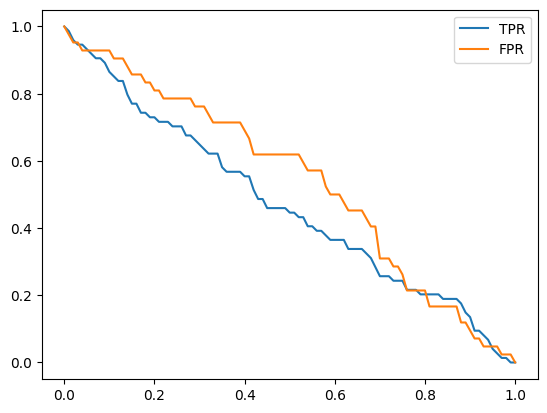

In [52]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

In [53]:
scores = []
thresholds = np.linspace(0, 1, 101)
 
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
 
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
 
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
 
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
 
    scores.append((t, tp, tn, fp, fn))
 
scores

[(np.float64(0.0), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.01), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.02), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.03), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.04), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.05), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.06), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.07), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.08), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.09), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.1), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.11), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.12), np.int64(74), np.int64(0), np.int64(42), np.int64(0)),
 (np.float64(0.13), np.int6

In [54]:
columns = ['threshold', 'tp', 'tn', 'fp', 'fn']


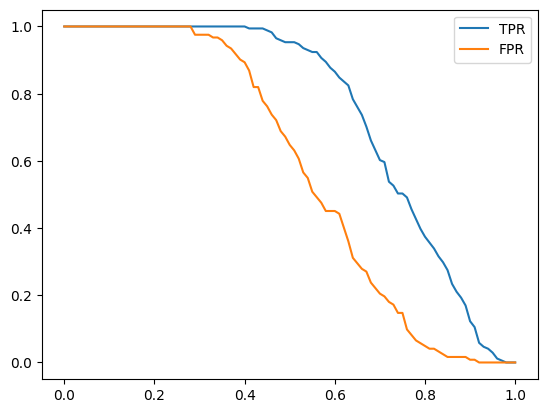

In [55]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()


In [56]:
#  Question 3 answer 0.745

In [57]:
# Question 4: F1 score
F1 = 2 * (precision * recall) / (precision + recall)
# compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

In [ ]:
#  Question 4 answer 0.14
  